# NYC Airbnb 2019 Data Analysis

Exploratory data analysis project on NYC Airbnb listings. The notebook explores listing prices, room types, neighbourhood groups, availability, reviews, missing values, and geographic listing distribution.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv
/kaggle/input/new-york-city-airbnb-open-data/New_York_City_.png


# About Dataset

## Context
Since 2008, guests and hosts have used Airbnb to expand on traveling possibilities and present a more unique, personalized way of experiencing the world. This dataset describes the listing activity and metrics in NYC, NY for 2019.

## Content
This data file includes all the necessary information to learn more about hosts, geographical availability, and key metrics needed to make predictions and draw conclusions.

## Acknowledgements
This public dataset is part of Airbnb, and the original source can be found on [this website](https://www.airbnb.com/).

## Inspiration
- What can we learn about different hosts and areas?
- What can we learn from predictions? (e.g., locations, prices, reviews, etc.)
- Which hosts are the busiest and why?
- Is there any noticeable difference in traffic among different areas, and what could be the reason for it?


# **importing libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')

# **Exploring data**

In [4]:
import os

DATA_PATH = '/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'AB_NYC_2019.csv'

df = pd.read_csv(DATA_PATH)
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Converting data type to a suitable one

In [6]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [8]:
df.duplicated().sum()

0

In [9]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
df.isna().mean()[df.isna().sum()>0].round(3)

name                 0.000
host_name            0.000
last_review          0.206
reviews_per_month    0.206
dtype: float64

In [11]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


In [12]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

# **profile report**
 using ydata profiling

In [13]:
profile = ProfileReport(df, title='Pandas Profiling Report', explorative=True)
profile.to_file("profiling_report.html")
sns.set_theme()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
profile.to_file("profiling_report.html")
from IPython.display import FileLink

# Creates a clickable download link
FileLink('profiling_report.html')


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

/kaggle/working/profiling_report.html

# **numerical columns dataframe**
for histogram visualization

In [15]:
num_cols = df.select_dtypes(include = np.number).columns.to_list()
num_cols.remove('latitude')
num_cols.remove('longitude')
num_cols

['id',
 'host_id',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

# **Visualizing num_cols**

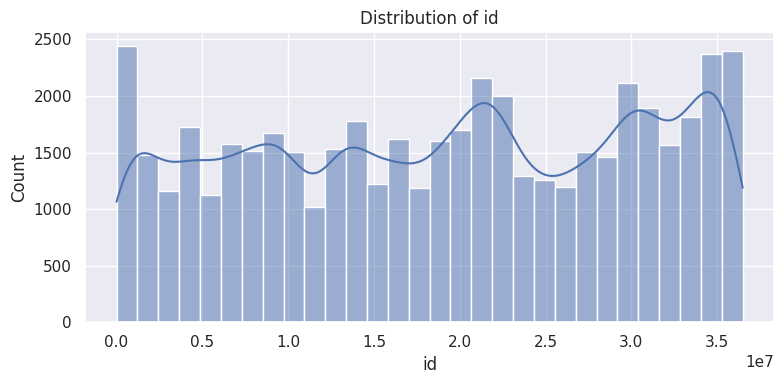

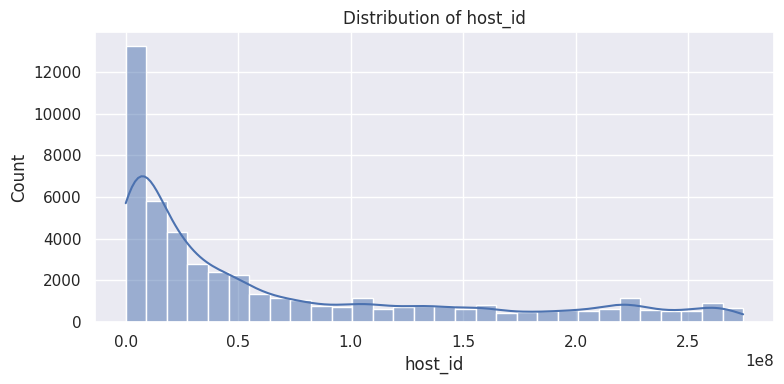

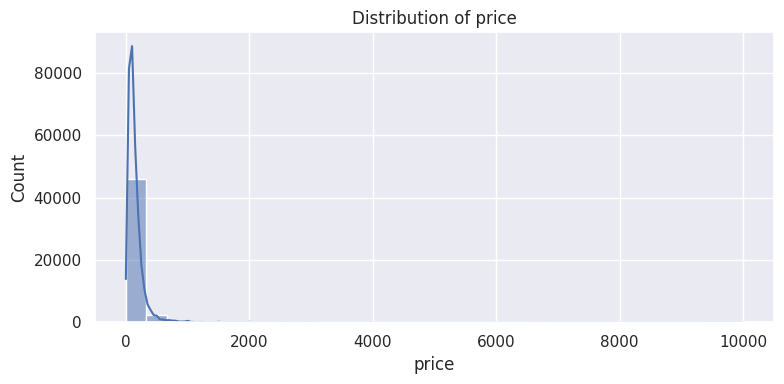

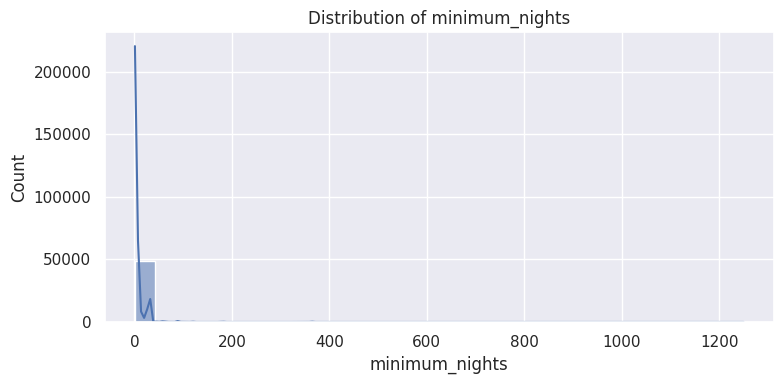

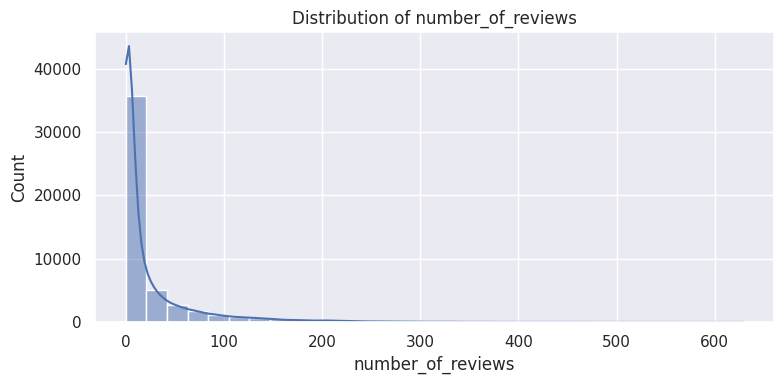

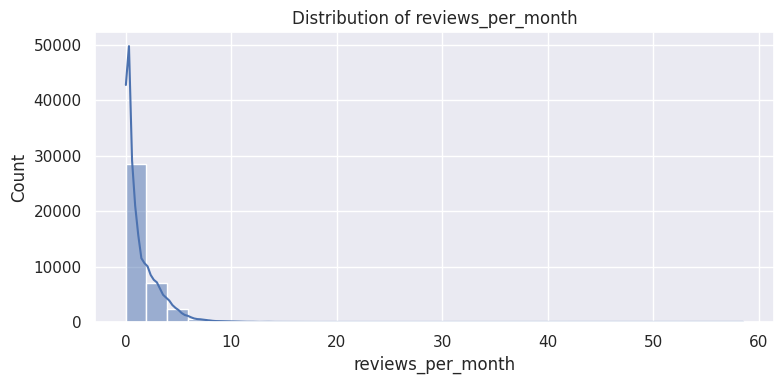

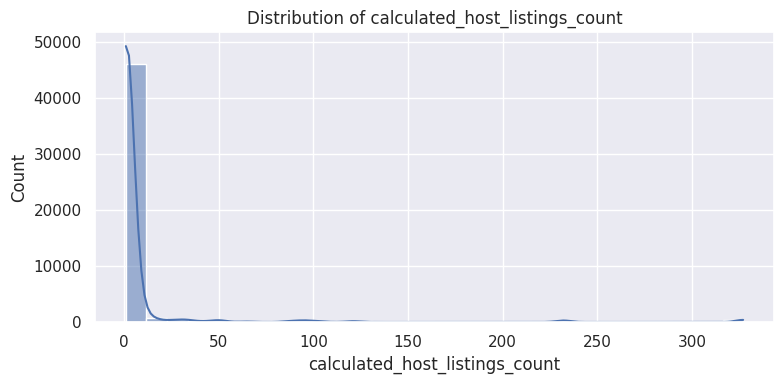

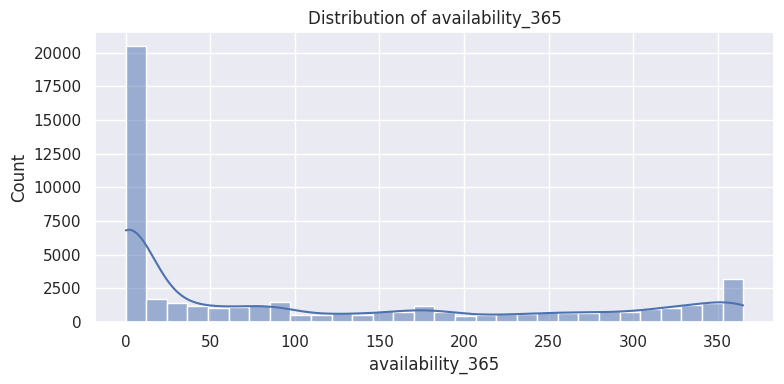

In [16]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

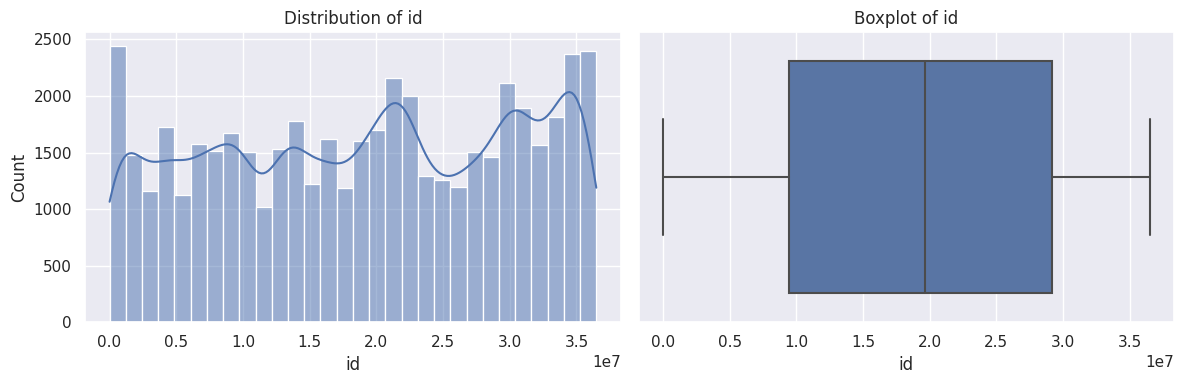

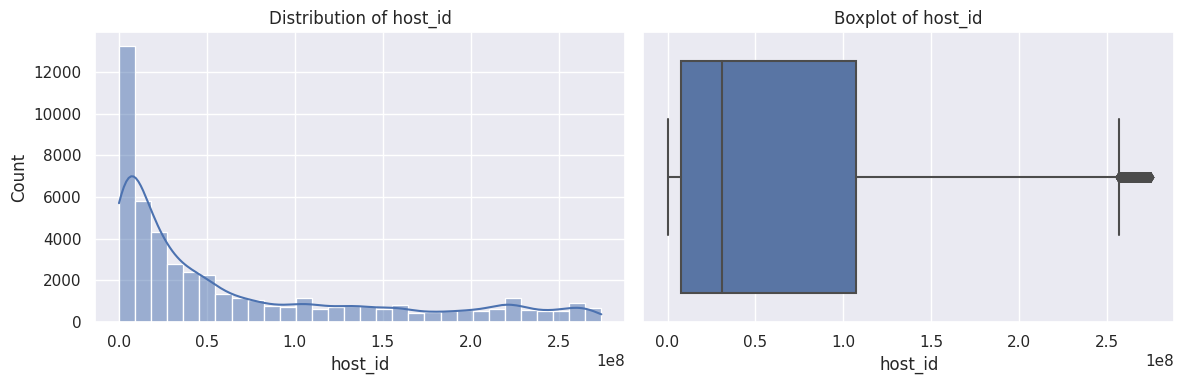

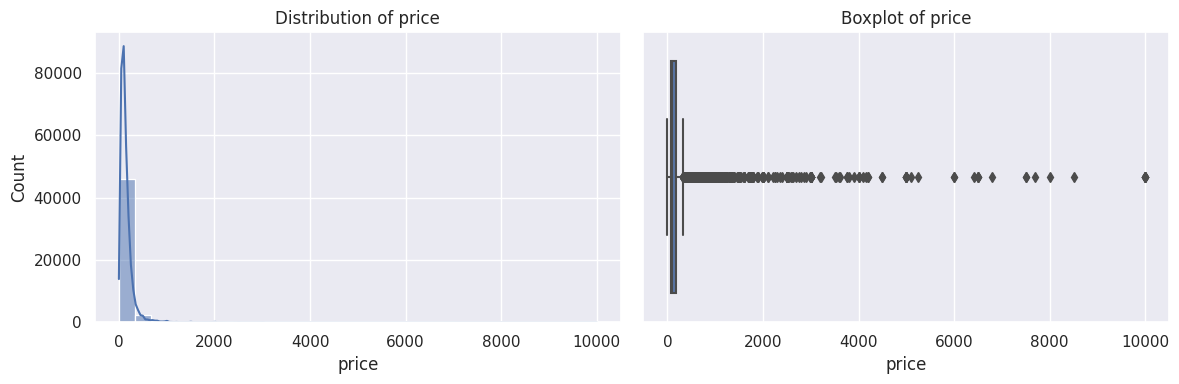

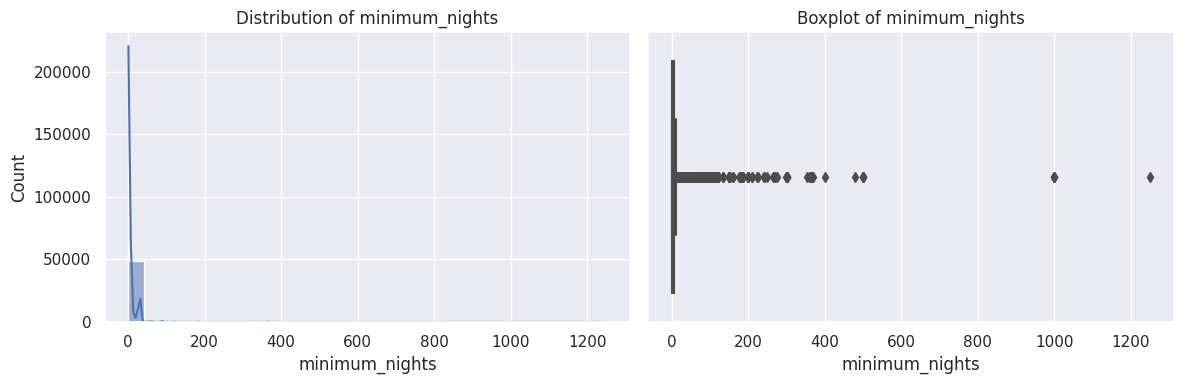

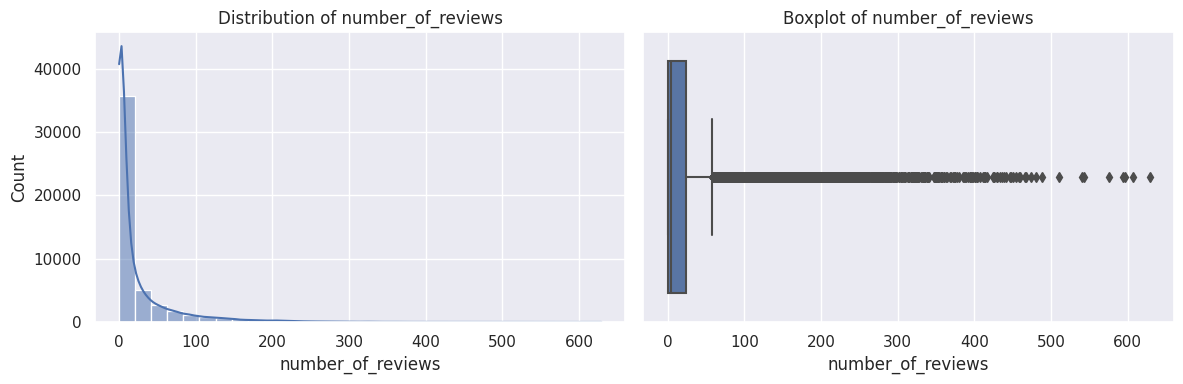

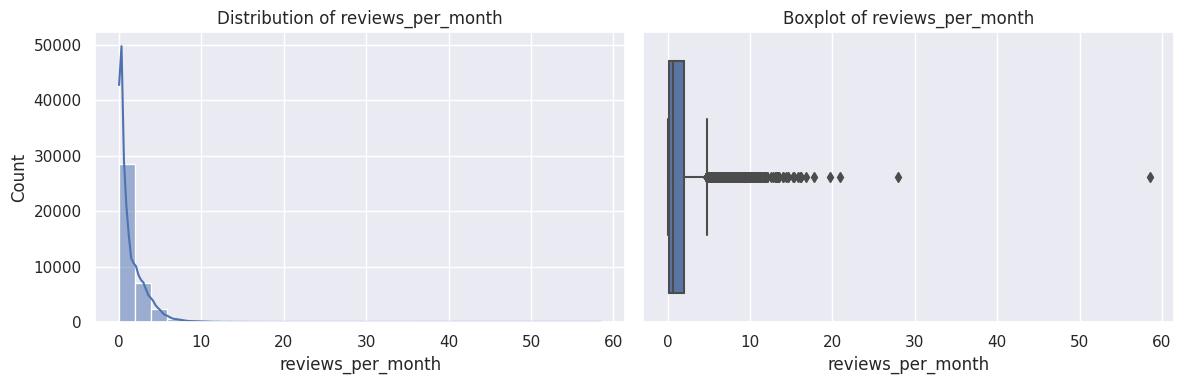

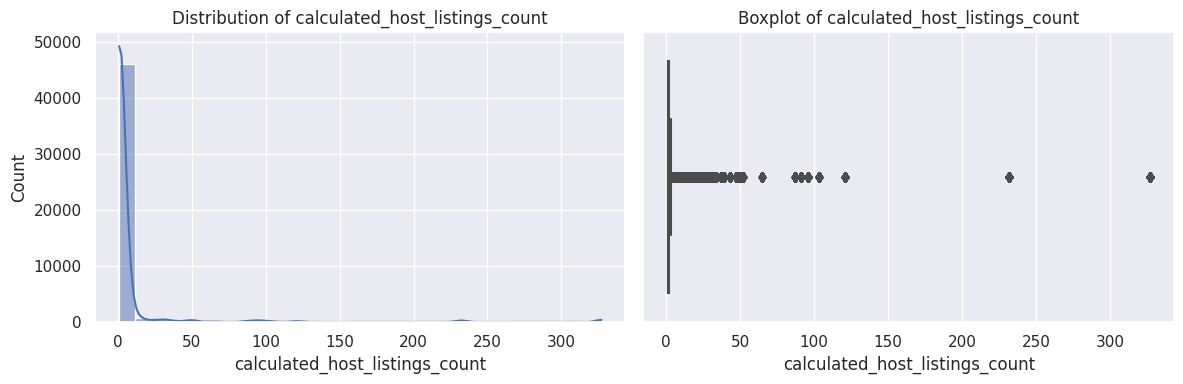

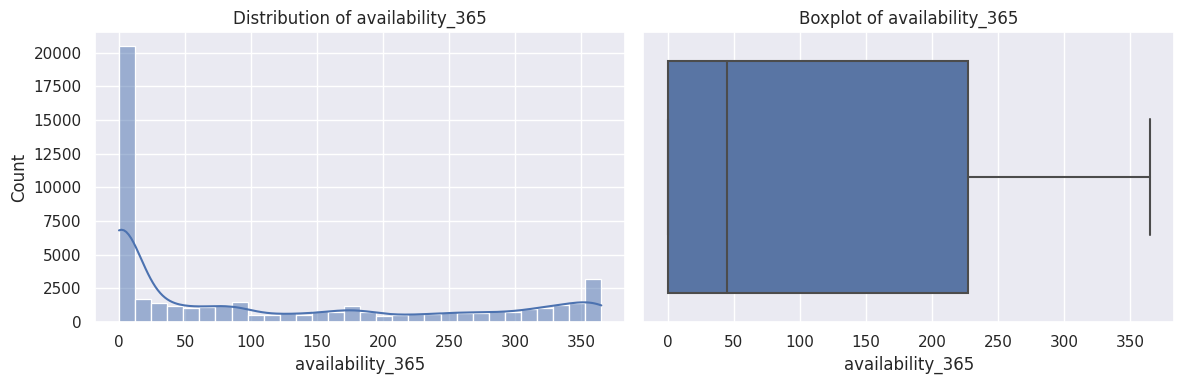

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming num_cols is your list of numeric columns (e.g., num_cols = ['Year', 'Engine', 'Power', etc.])
for col in num_cols:
    # Create a figure with two subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot histogram with KDE on the first subplot
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    
    # Plot boxplot on the second subplot
    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# **Categorical cols**

In [17]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

cat_cols

['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']

# **visualizing cat_cols**


Analysis for: name
name
Hillside Hotel                                        0.036826
Home away from home                                   0.034780
New york Multi-unit building                          0.032734
Brooklyn Apartment                                    0.024550
Loft Suite @ The Box House Hotel                      0.022505
                                                        ...   
Large 1BR Apt. in Williamsburg                        0.002046
Feel at Home                                          0.002046
Spacious Modern Alcove Studio in a Luxury Building    0.002046
Artist's Room in Large Apartment                      0.002046
Trendy duplex in the very heart of Hell's Kitchen     0.002046
Name: proportion, Length: 47905, dtype: float64


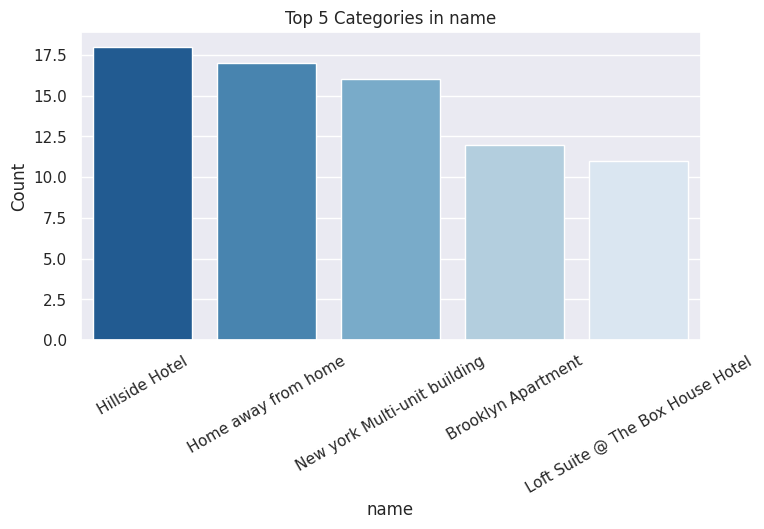


Analysis for: host_name
host_name
Michael              0.853214
David                0.824569
Sonder (NYC)         0.669067
John                 0.601547
Alex                 0.570856
                       ...   
Rhonycs              0.002046
Brandy-Courtney      0.002046
Shanthony            0.002046
Aurore And Jamila    0.002046
Ilgar & Aysel        0.002046
Name: proportion, Length: 11452, dtype: float64


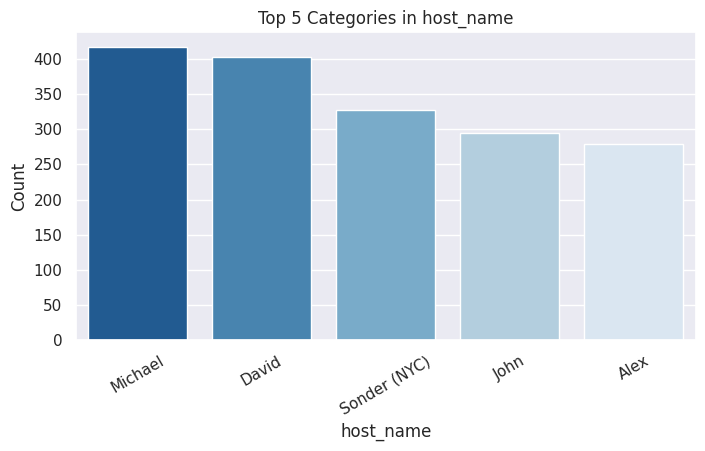


Analysis for: neighbourhood_group
neighbourhood_group
Manhattan        44.301053
Brooklyn         41.116679
Queens           11.588097
Bronx             2.231312
Staten Island     0.762859
Name: proportion, dtype: float64


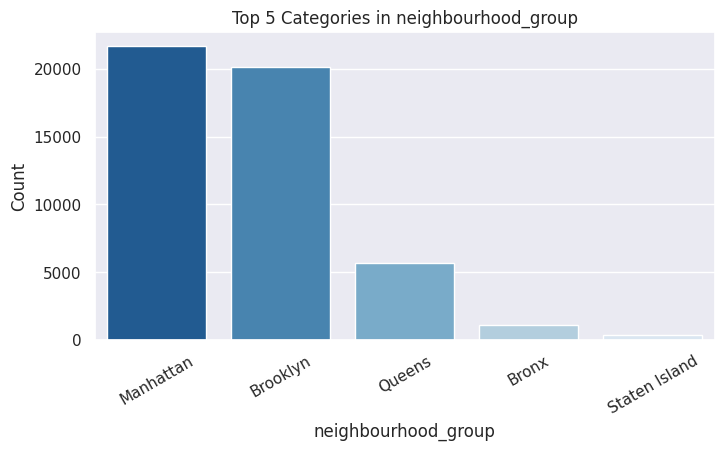


Analysis for: neighbourhood
neighbourhood
Williamsburg          8.017180
Bedford-Stuyvesant    7.595869
Harlem                5.436139
Bushwick              5.041415
Upper West Side       4.031087
                        ...   
Fort Wadsworth        0.002045
Richmondtown          0.002045
New Dorp              0.002045
Rossville             0.002045
Willowbrook           0.002045
Name: proportion, Length: 221, dtype: float64


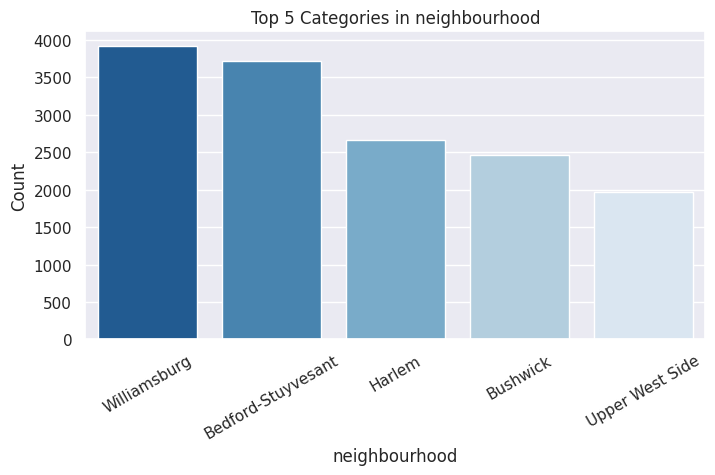


Analysis for: room_type
room_type
Entire home/apt    51.966459
Private room       45.661111
Shared room         2.372431
Name: proportion, dtype: float64


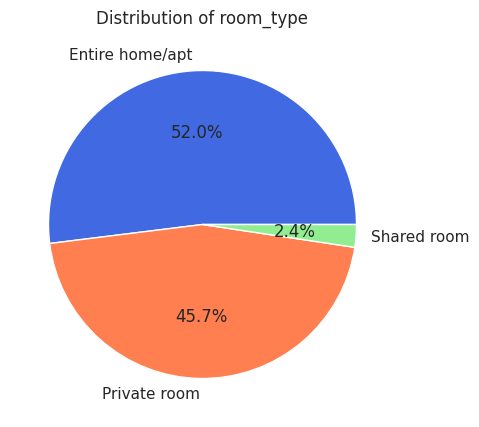


Analysis for: last_review
last_review
2019-06-23    3.637721
2019-07-01    3.498700
2019-06-30    3.452359
2019-06-24    2.252658
2019-07-07    1.848467
                ...   
2012-12-25    0.002574
2013-10-01    0.002574
2014-05-29    0.002574
2014-04-19    0.002574
2018-03-29    0.002574
Name: proportion, Length: 1764, dtype: float64


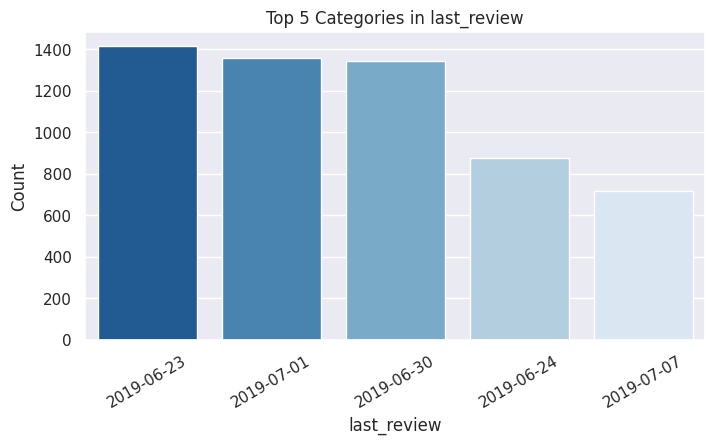

In [29]:
cat_cols = df.select_dtypes(exclude=np.number).columns

def univ_cat(data, cols, top=5):
    print(f'\nAnalysis for: {cols}\n{"="*80}')
    print(data[cols].value_counts(normalize=True) * 100)
    
    tops = data[cols].value_counts().nlargest(top)
    
    if data[cols].nunique() < 5:
        plt.figure(figsize=(6, 5))
        plt.pie(tops.values, labels=tops.index, autopct='%1.1f%%', 
                colors=['royalblue', 'coral', 'lightgreen', 'gold', 'purple'])
        plt.title(f'Distribution of {cols}')
        plt.show()
    else:
        plt.figure(figsize=(8, 4))
        sns.barplot(x=tops.index, y=tops.values, palette='Blues_r')
        plt.title(f'Top {top} Categories in {cols}')
        plt.xlabel(cols)
        plt.ylabel('Count')
        plt.xticks(rotation=30)
        plt.show()

for col in cat_cols:
    univ_cat(df, col)

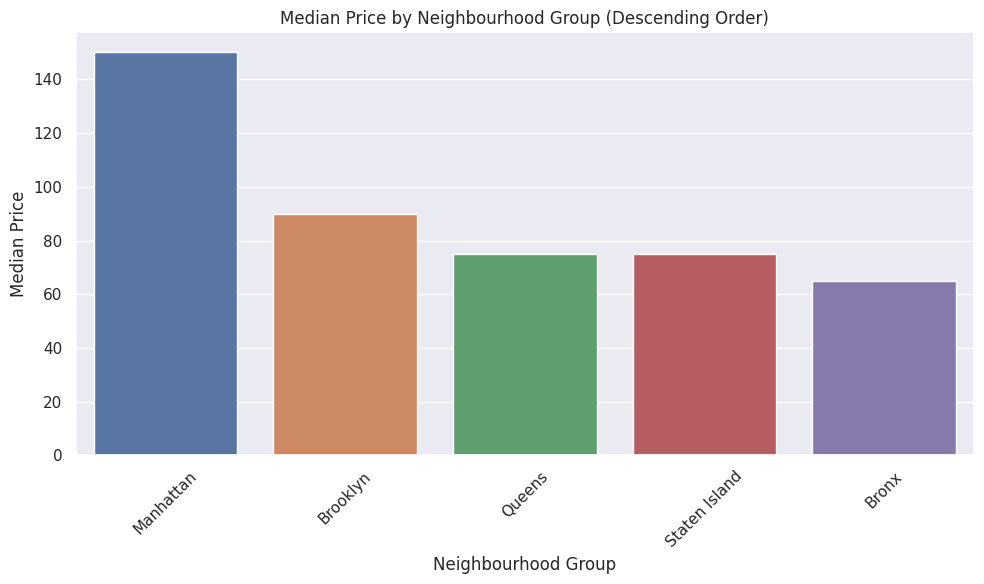

In [34]:
median_prices = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=median_prices.index,y=median_prices.values
)

plt.title('Median Price by Neighbourhood Group (Descending Order)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Median Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

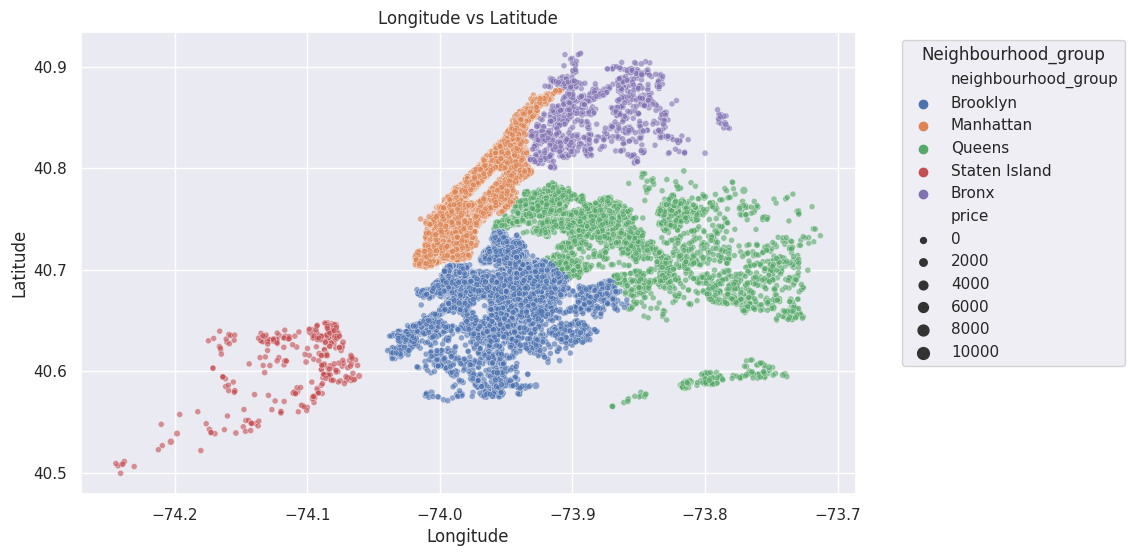

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='longitude', y='latitude', data=df,hue='neighbourhood_group', alpha=0.6 ,size="price")

plt.title('Longitude vs Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood_group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
df.price.quantile([0.75,0.80,0.85,0.90,0.95,1.00])

0.75      175.0
0.80      200.0
0.85      225.0
0.90      269.0
0.95      355.0
1.00    10000.0
Name: price, dtype: float64

In [52]:
pivot_table = pd.pivot_table(df, values='price', index='neighbourhood_group', columns='room_type', aggfunc='median')
pivot_table.style.highlight_max(axis=0)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.000000,53.500000,40.000000
Brooklyn,145.000000,65.000000,36.000000
Manhattan,191.000000,90.000000,69.000000
Queens,120.000000,60.000000,37.000000
Staten Island,100.000000,50.000000,30.000000
